# **Q1**

**At junction V2:**
$$\frac{V_2-V_1}{R} + \frac{V_2-V_3}{R} + \frac{V_2-V_4}{R} + \frac{V_2}{R} = 0$$
$$-V_1 + 4V_2 - V_3 - V_4 = 0$$

**At junction V3:**
$$\frac{V_3-V_+}{R} + \frac{V_3-V_1}{R} + \frac{V_3-V_2}{R} + \frac{V_3-V_4}{R} = 0$$
$$-V_1 - V_2 + 4V_3 - V_4 = V_+$$

**At junction V4:**
$$\frac{V_4-V_1}{R} + \frac{V_4-V_2}{R} + \frac{V_4-V_3}{R} + \frac{V_4}{R} = 0$$
$$-V_1 - V_2 - V_3 + 4V_4 = 0$$

In [66]:
import numpy as np

def gausselim(Amat, b):
	n = np.shape(Amat)[0]
	for i in range(n):
		if np.abs(Amat[i,i]/max(abs(Amat[i,i:]))) < 1.e-10:
			print("pivot is small!")
			return
		else:
			for j in range(i+1, n):    
				fac = Amat[j,i] / Amat[i,i]
				Amat[j,i+1:] -= fac * Amat[i,i+1:]  
				b[j] -= fac * b[i]
	return b


def BackSub(Amat, b):
	n = len(b)
	x = np.zeros(n)
	for i in range(n-1, -1, -1):
		x[i] = (b[i] - np.dot(Amat[i, i+1:], x[i+1:])) / Amat[i,i]
	return x


Vplus = 5.0

A = np.array([[ 4, -1, -1, -1],
              [-1,  4, -1, -1],
              [-1, -1,  4, -1],
              [-1, -1, -1,  4]], dtype= float)

b = np.array([Vplus, 0, Vplus, 0], dtype= float)

b_upper = gausselim(A, b)
x       = BackSub(A, b_upper)

print(f"V1 = {x[0]:.6f}")
print(f"V2 = {x[1]:.6f}")
print(f"V3 = {x[2]:.6f}")
print(f"V4 = {x[3]:.6f}")

V1 = 3.000000
V2 = 2.000000
V3 = 3.000000
V4 = 2.000000


# **Q2**

In [67]:
# 2a

def GElim(Amat, b):
	n = np.shape(Amat)[0]

	for i in range(n):
		ipivot = i
		for j in range(i+1, n):
			if abs(Amat[ipivot,i]/max(abs(Amat[ipivot,i:]))) < abs(Amat[j,i]/max(abs(Amat[j,i:]))):
				ipivot = j
		Amat[[i, ipivot]] = Amat[[ipivot, i]]
		b[[i, ipivot]] = b[[ipivot, i]]

		if np.abs(Amat[i,i]/max(abs(Amat[i,i:]))) < 1.e-10:
			print("pivot is small!")
			return
		else:
			for j in range(i+1, n):    
				fac = Amat[j,i] / Amat[i,i]
				Amat[j,i+1:] -= fac * Amat[i,i+1:]   
				b[j] -= fac * b[i]
	return b


# back substitution to get the solution
def BackSub(Amat, b):
	n = len(b)
	x = np.zeros(n)
	for i in range(n-1, -1, -1):
		x[i] = (b[i] - np.dot(Amat[i, i+1:], x[i+1:])) / Amat[i,i]
	return x


Vplus = 5.0

A = np.array([[ 4, -1, -1, -1],
              [-1,  4, -1, -1],
              [-1, -1,  4, -1],
              [-1, -1, -1,  4]], dtype= float)

b = np.array([Vplus, 0, Vplus, 0], dtype= float)

b_upper = GElim(A, b)
x = BackSub(A, b_upper)

print(f"V1 = {x[0]:.6f}")
print(f"V2 = {x[1]:.6f}")
print(f"V3 = {x[2]:.6f}")
print(f"V4 = {x[3]:.6f}")

V1 = 3.000000
V2 = 2.000000
V3 = 3.000000
V4 = 2.000000


In [68]:
# 2b

A_matrix2b = np.array([[0,1,4,1],
                    [3,4,-1,-1],
                    [1,-4,1,5],
                    [2,-2,1,3]], dtype=float)

b_column2b = np.array([-4,3,9,7], dtype=float)

b_upper2b = GElim(A_matrix2b,b_column2b)
x2b = BackSub(A_matrix2b,b_upper2b)

print(f"w = {x2b[0]:.8f}")
print(f"x = {x2b[1]:.8f}")
print(f"y = {x2b[2]:.8f}")
print(f"z = {x2b[3]:.8f}")

w = 1.61904762
x = -0.42857143
y = -1.23809524
z = 1.38095238


# **Problem 3**

In [69]:
from numpy.linalg import solve

Vplus = 5.0

A = np.array([[ 4, -1, -1, -1],
              [-1,  4, -1, -1],
              [-1, -1,  4, -1],
              [-1, -1, -1,  4]])

b = np.array([Vplus, 0, Vplus, 0])


solve(A,b)

array([3., 2., 3., 2.])

# **Problem 4**

## **Q4(a)** 

**At junction 1:** (connected to $V_+$ via $R_1$, to ground via $R_4$, and to junction 2 via $C_1$)
$$\frac{V_1 - V_+}{R_1} + \frac{V_1}{R_4} + C_1\frac{d(V_1 - V_2)}{dt} = 0$$

**At junction 2:** (connected to $V_+$ via $R_2$, to ground via $R_5$, to junction 1 via $C_1$, and to junction 3 via $C_2$)
$$\frac{V_2 - V_+}{R_2} + \frac{V_2}{R_5} + C_1\frac{d(V_2 - V_1)}{dt} + C_2\frac{d(V_2 - V_3)}{dt} = 0$$

**At junction 3:** (connected to $V_+$ via $R_3$, to ground via $R_6$, and to junction 2 via $C_2$)
$$\frac{V_3 - V_+}{R_3} + \frac{V_3}{R_6} + C_2\frac{d(V_3 - V_2)}{dt} = 0$$

**Substitution** $V_i = x_i e^{i\omega t}$, $\quad V_+ = x_+ e^{i\omega t}$

Since $\frac{d}{dt}(x_i e^{i\omega t}) = i\omega x_i e^{i\omega t}$, dividing through by $e^{i\omega t}$:

**Junction 1:**
$$\frac{x_1 - x_+}{R_1} + \frac{x_1}{R_4} + i\omega C_1(x_1 - x_2) = 0$$
$$\left(\frac{1}{R_1} + \frac{1}{R_4} + i\omega C_1\right)x_1 - i\omega C_1\, x_2 = \frac{x_+}{R_1}$$

**Junction 2:**
$$\frac{x_2 - x_+}{R_2} + \frac{x_2}{R_5} + i\omega C_1(x_2 - x_1) + i\omega C_2(x_2 - x_3) = 0$$
$$-i\omega C_1\, x_1 + \left(\frac{1}{R_2} + \frac{1}{R_5} + i\omega C_1 + i\omega C_2\right)x_2 - i\omega C_2\, x_3 = \frac{x_+}{R_2}$$

**Junction 3:**
$$\frac{x_3 - x_+}{R_3} + \frac{x_3}{R_6} + i\omega C_2(x_3 - x_2) = 0$$
$$-i\omega C_2\, x_2 + \left(\frac{1}{R_3} + \frac{1}{R_6} + i\omega C_2\right)x_3 = \frac{x_+}{R_3}$$

In [ ]:
from cmath import polar, phase
R1 = 1e3
R2 = 2e3
R3 = 1e3
R4 = 2e3
R5 = 1e3
R5 = 2e3
R6 = 1e3
C1 = 1e-6
C2 = 0.5e-6
xplus = 3.0
omega = 1000.0

A = np.array([
	[1/R1+1/R4+1j*omega*C1,-1j*omega*C1,0],
	[-1j*omega*C1,1/R2+1/R5+1j*omega*C1+1j*omega*C2,-1j*omega*C2],
	[0,-1j*omega*C2,1/R3+1/R6+1j*omega*C2]], dtype=complex)

b = np.array([xplus/R1, xplus/R2, xplus/R3], dtype=complex)

x = np.linalg.solve(A, b)

for i, xi in enumerate(x):
	r, theta = polar(xi)
	print(f"V{i+1}: amplitude = {r:.6f} V,  phase = {np.degrees(theta):.6f} degrees")

V1: amplitude = 1.877733 V,  phase = -3.556181 degrees
V2: amplitude = 1.700951 V,  phase = 2.437912 degrees
V3: amplitude = 1.495582 V,  phase = 1.960955 degrees


# **Problem 5**

In [71]:
def QR_GS(A):
    n = np.shape(A)[0]
    V = 1.*A
    Q = 0*A
    R = np.zeros((n,n))

    for i in range(n):
        R[i,i] = np.linalg.norm(V[:,i])
        Q[:,i] = V[:,i]/R[i,i]
        R[i,i+1:] = np.matmul(Q[:,i].T, V[:,i+1:])
        V[:,i+1:] -= np.outer(Q[:,i], R[i,i+1:])
    return Q,R

A5  = np.array([[1,4,8,4],
                [4,2,3,7],
                [8,3,6,9],
                [4,7,9,2]],dtype=float)
Q5,R5 = QR_GS(A5)
print(f'Q = {Q5}')
print(f'R = {R5}')

A_multi = np.matmul(Q5,R5)
print(f'QR = {A_multi}')
print('As QR = A, so the method works')

Q = [[ 0.10153462  0.558463    0.80981107  0.1483773 ]
 [ 0.40613847 -0.10686638 -0.14147555  0.8964462 ]
 [ 0.81227693 -0.38092692  0.22995024 -0.37712564]
 [ 0.40613847  0.72910447 -0.5208777  -0.17928924]]
R = [[ 9.8488578   6.49821546 10.55960012 11.37187705]
 [ 0.          5.98106979  8.4234836  -0.484346  ]
 [ 0.          0.          2.74586406  3.27671222]
 [ 0.          0.          0.          3.11592335]]
QR = [[1. 4. 8. 4.]
 [4. 2. 3. 7.]
 [8. 3. 6. 9.]
 [4. 7. 9. 2.]]
As QR = A, so the method works


In [72]:
def eigsys(A):
    tol = 1e-6
    err = 1e10
    V = np.identity(np.shape(A)[0])
    while err> tol:
        Q,R = QR_GS(A)
        A = np.matmul(R,Q)
        V = np.matmul(V,Q)
        lowmat_norm = np.linalg.norm(np.tril(A))
        diag_norm = np.linalg.norm(np.diag(A))
        err = (lowmat_norm - diag_norm)/diag_norm
    return [np.diag(A), V]


A5  = np.array([[1,4,8,4],
                [4,2,3,7],
                [8,3,6,9],
                [4,7,9,2]],dtype=float)

eigenvals = eigsys(A5)[0]
print(f'The eigenvalues are {", ".join(map(lambda x: f"{x:.8f}", eigenvals))}')

The eigenvalues are 20.99996893, -7.99996725, -2.99999834, 0.99999665


# **Problem 6**

## **6a**

Substitute $\psi(x) = \sum_n \psi_n \sin\frac{\pi n x}{L}$ into $\hat{H}\psi = E\psi$, multiply both sides by $\sin\frac{\pi m x}{L}$ and integrate from $0$ to $L$:

$$\sum_n \psi_n \int_0^L \sin\frac{\pi m x}{L}\, \hat{H} \sin\frac{\pi n x}{L}\, dx = E \sum_n \psi_n \int_0^L \sin\frac{\pi m x}{L} \sin\frac{\pi n x}{L}\, dx$$

By orthogonality the RHS $= \frac{1}{2}LE\psi_m$, so:

$$\sum_n \psi_n \int_0^L \sin\frac{\pi m x}{L}\, \hat{H} \sin\frac{\pi n x}{L}\, dx = \frac{1}{2}LE\psi_m$$

Multiplying both sides by $\frac{2}{L}$ and defining:

$$H_{mn} = \frac{2}{L}\int_0^L \sin\frac{\pi m x}{L}\, \hat{H} \sin\frac{\pi n x}{L}\, dx$$

we get $\sum_n H_{mn}\psi_n = E\psi_m$, i.e. $H\psi = E\psi$. So $\psi$ is an eigenvector of $H$ with eigenvalue $E$.

In [73]:

hbar = 1.0546e-34
M    = 9.1094e-31
e    = 1.6022e-19
L    = 5e-10       
a    = 10 * e       

def Hmn(m, n):
	kinetic = (hbar**2 * np.pi**2 * n**2) / (2 * M * L**2) if m == n else 0.0
	if m == n:
		potential = a/2
	elif (m % 2) != (n % 2):   
		potential = -(8 * a / np.pi**2) * m*n / (m**2 - n**2)**2
	else:  
		potential = 0.0
	return kinetic + potential


In [74]:
H10 = np.zeros((10, 10))
for m in range(1, 11):
	for n in range(1, 11):
		H10[m-1, n-1] = Hmn(m, n)
eigenvals10, eigenvecs10 = np.linalg.eigh(H10)
print(f'Ground state energy = {eigenvals10[0]/e:.8f} eV')
print(f'Energy of 1st excited state = {eigenvals10[1]/e:.8f} eV')
print(f'Energy of 2nd excited state = {eigenvals10[2]/e:.8f} eV')
print(f'Energy of 3rd excited state = {eigenvals10[3]/e:.8f} eV')
for i in range(4,10):
	print(f'Energy of {i}th excited state = {eigenvals10[i]/e:.8f} eV')

Ground state energy = 5.83645417 eV
Energy of 1st excited state = 11.18131295 eV
Energy of 2nd excited state = 18.66338897 eV
Energy of 3rd excited state = 29.14508710 eV
Energy of 4th excited state = 42.65646704 eV
Energy of 5th excited state = 59.18726400 eV
Energy of 6th excited state = 78.73209166 eV
Energy of 7th excited state = 101.28905200 eV
Energy of 8th excited state = 126.85590205 eV
Energy of 9th excited state = 155.56090008 eV


In [75]:
H100 = np.zeros((100, 100))
for m in range(1, 101):
	for n in range(1, 101):
		H100[m-1, n-1] = Hmn(m, n)
eigenvals100, eigenvecs100 = np.linalg.eigh(H100)
print(f'Ground state energy = {eigenvals100[0]/e:.8f} eV')
print(f'Energy of 1st excited state = {eigenvals100[1]/e:.8f} eV')
print(f'Energy of 2nd excited state = {eigenvals100[2]/e:.8f} eV')
print(f'Energy of 3rd excited state = {eigenvals100[3]/e:.8f} eV')
for i in range(4,10):
	print(f'Energy of {i}th excited state = {eigenvals100[i]/e:.8f} eV')

Ground state energy = 5.83645377 eV
Energy of 1st excited state = 11.18131162 eV
Energy of 2nd excited state = 18.66338710 eV
Energy of 3rd excited state = 29.14507830 eV
Energy of 4th excited state = 42.65645792 eV
Energy of 5th excited state = 59.18721141 eV
Energy of 6th excited state = 78.73203984 eV
Energy of 7th excited state = 101.28842109 eV
Energy of 8th excited state = 126.85506978 eV
Energy of 9th excited state = 155.43128240 eV


Obviously 100x100 hamiltonian gives more accurate values of energy. This is because in reality the Hamiltonian is infinite dimensional, but we are truncating it at finite N which results in errors


State 1 normalization check = 1.000000
State 2 normalization check = 1.000000
State 3 normalization check = 1.000000


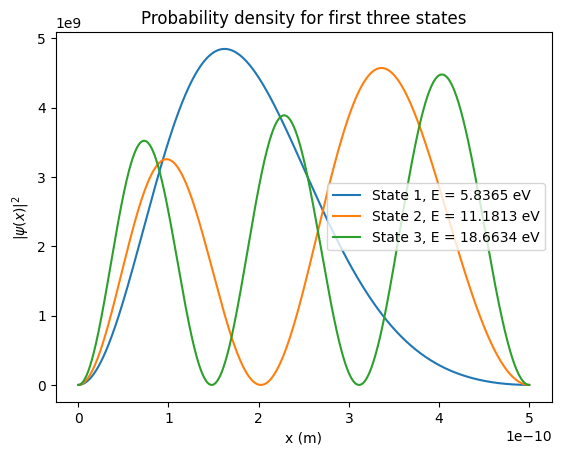

In [76]:
import matplotlib.pyplot as plt

N = 100
x = np.linspace(0, L, 2000)

def wavefunction(coeffs, x):
    psi = np.zeros_like(x, dtype=float)
    for n in range(1, N+1):
        psi += coeffs[n-1] * np.sin(n * np.pi * x / L)
    return psi

fig, ax = plt.subplots()
for state in range(3):
    psi = wavefunction(eigenvecs100[:, state], x)
    norm = np.trapezoid(psi**2, x)
    psi = psi / np.sqrt(norm)
    prob = psi**2
    E_ev = eigenvals100[state] / e
    ax.plot(x, prob, label=f'State {state+1}, E = {E_ev:.4f} eV')
    print(f'State {state+1} normalization check = {np.trapezoid(prob, x):.6f}')

ax.set_xlabel('x (m)')
ax.set_ylabel(r'$|\psi(x)|^2$')
ax.set_title('Probability density for first three states')
ax.legend()
plt.show()

# **Problem 7**


### **7a**

 $\dot{x} = 0$ and $\dot{y} = 0$:

$$-x + ay + x^2y = 0$$
$$b - ay - x^2y = 0$$

Adding both equations:

$$-x + b = 0 \quad \Rightarrow \quad x = b$$

Substituting $x = b$ into the second equation:

$$b - ay - b^2y = 0 \quad \Rightarrow \quad b = y(a + b^2) \quad \Rightarrow \quad y = \frac{b}{a + b^2}$$


### **7b**

Using x = b , we get
$$ y = \frac{b}{a + b^2} = \frac{x}{a + x^2} $$


Applying the relaxation method: guess an initial $x_0, y_0$, then iterate:

$$x_{n+1} = y_n(a + x_n^2), \qquad y_{n+1} = \frac{b}{a + x_n^2}$$

until convergence. 



In [77]:
a, b   = 1.0, 2.0
x, y   = 1.0, 1.0    # initial guess

for i in range(10000):
	x_new = y * (a + x**2)
	y_new = b / (a + x**2)
	if abs(x_new - x) < 1e-6 and abs(y_new - y) < 1e-6:
		print(f'Converged at x={x_new:.6f}, y={y_new:.6f}')
		break
	x, y = x_new, y_new
else:
	print(f'Did not converge. Last values: x={x:.6f}, y={y:.6f}')

Did not converge. Last values: x=0.622003, y=1.999925


### **7c**


Adding both equations gives $x = b$. So rearrange as:

$$x_{n+1} = b, \qquad y_{n+1} = \frac{b}{a + x_n^2}$$


In [78]:
a, b = 1.0, 2.0
x, y = 1.0, 1.0

for i in range(1000):
	x_new = b
	y_new = b / (a + x**2)
	if abs(x_new - x) < 1e-6 and abs(y_new - y) < 1e-6:
		print(f'Converged at x={x_new:.6f}, y={y_new:.6f}')
		break
	x, y = x_new, y_new

print(f'Analytic:  x={b:.6f}, y={b/(a+b**2):.6f}')


Converged at x=2.000000, y=0.400000
Analytic:  x=2.000000, y=0.400000


# **Problem 8**

Differentiating $I(\lambda) = \frac{2\pi hc^2 \lambda^{-5}}{e^{hc/\lambda k_BT} - 1}$ and setting $\frac{dI}{d\lambda} = 0$:

Let $x = \frac{hc}{\lambda k_B T}$, then the condition reduces to:

$$5\left(1 - e^{-x}\right) = x$$

or equivalently:

$$f(x) = \frac{xe^x}{e^x - 1} - 5 = 0$$


In [79]:
def f(x):
	return x * np.exp(x) / (np.exp(x) - 1) - 5

a, b = 1.0, 10.0
eps  = 1e-6

while abs(b - a) > eps:
	mid = (a + b) / 2
	if f(mid) * f(a) < 0:
		b = mid
	else:
		a = mid

x_sol = (a + b) / 2
print(f'x = hc/lambda_max*kB*T = {x_sol:.6f}')

#  b = hc / (x * kB)
h  = 6.626e-34
c  = 3.0e8
kB = 1.381e-23

b_wien = h * c / (x_sol * kB)
print(f'Wien displacement constant b = {b_wien:.6e} m·K')

lambda_sun = 502e-9    
T_sun = b_wien / lambda_sun
print(f'Surface temperature of the Sun = {T_sun:.1f} K')



x = hc/lambda_max*kB*T = 4.965114
Wien displacement constant b = 2.899010e-03 m·K
Surface temperature of the Sun = 5774.9 K


# **Problem 9**

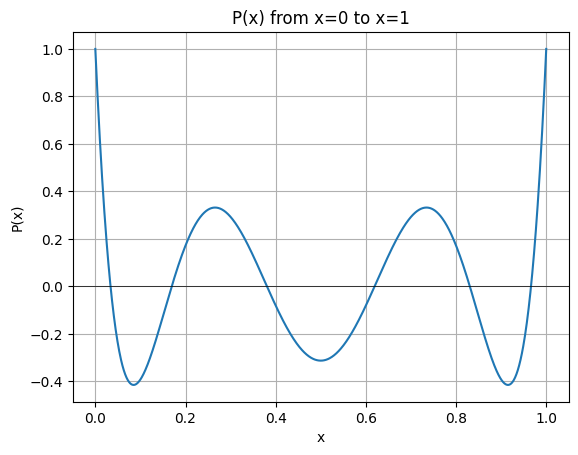

In [80]:
def P(x):
	return 924*x**6 - 2772*x**5 + 3150*x**4 - 1680*x**3 + 420*x**2 - 42*x + 1

def dP(x):
	return 6*924*x**5 - 5*2772*x**4 + 4*3150*x**3 - 3*1680*x**2 + 2*420*x - 42

# 9a: plot
x = np.linspace(0, 1, 1000)
plt.plot(x, P(x))
plt.axhline(0, color='k', linewidth=0.5)
plt.xlabel('x')
plt.ylabel('P(x)')
plt.title('P(x) from x=0 to x=1')
plt.grid(True)
plt.show()


In [81]:
# 9b
def newton(x0, tol=1e-10):
	x = x0
	while True:
		x_new = x - P(x) / dP(x)
		if abs(x_new - x) < tol:
			return x_new
		x = x_new

# initial guesses from plot
x0s = [0,0.2,0.4,0.6,0.8,1]

roots = [newton(x0) for x0 in x0s]

for i, r in enumerate(roots):
	print(f'root {i+1}: x = {r:.10f},  P(x) = {P(r):.2e}')

root 1: x = 0.0337652429,  P(x) = 2.22e-16
root 2: x = 0.1693953068,  P(x) = 0.00e+00
root 3: x = 0.3806904070,  P(x) = 2.31e-14
root 4: x = 0.6193095930,  P(x) = -6.39e-14
root 5: x = 0.8306046932,  P(x) = -2.63e-13
root 6: x = 0.9662347571,  P(x) = 5.54e-13


# **Q10**

**At junction $V_1$:**
$$\frac{V_1 - V_+}{R_1} + \frac{V_1 - V_2}{R_2} + I_0\left(e^{(V_1-V_2)/V_T} - 1\right) = 0$$

**At junction $V_2$:**
$$\frac{V_2 - V_+}{R_3} + \frac{V_2}{R_4} - I_0\left(e^{(V_1-V_2)/V_T} - 1\right) = 0$$


In [82]:
Vplus = 5.0
R1, R2, R3, R4 = 1e3, 4e3, 3e3, 2e3
I0 = 3e-9
VT = 0.05
def f(V):
	V1, V2 = V
	I_diode = I0 * (np.exp((V1 - V2) / VT) - 1)
	f1 = (V1 - Vplus)/R1 + (V1 - V2)/R2 + I_diode
	f2 = (V2 - Vplus)/R3 + V2/R4 - I_diode
	return np.array([f1, f2])

def Jac(V):
	V1, V2 = V
	dI = (I0 / VT) * np.exp((V1 - V2) / VT)
	J = np.array([
		[1/R1 + 1/R2 + dI, -1/R2 - dI],
		[ -dI, 1/R3 + 1/R4 + dI]
	])
	return J

V = np.array([2.5, 2.5]) #Intial Guess    

while True:
	dV = np.linalg.solve(Jac(V), -f(V))
	V  = V + dV
	if np.max(np.abs(dV)) < 1e-10:
		break

print(f'V1 = {V[0]:.6f} V')
print(f'V2 = {V[1]:.6f} V')
print(f'Voltage across diode = {V[0]-V[1]:.6f} V')


V1 = 3.838714 V
V2 = 3.202755 V
Voltage across diode = 0.635960 V


So we see that voltage difference across the diode is approximately 0.6V as was mentioned